# feature explain

成功載入並處理了實際數據。
成功載入模型: 'Random_Forest_best_model.joblib'

--- Random Forest Feature Importance ---
             feature  importance
2             energy    0.206183
6   instrumentalness    0.197692
5       acousticness    0.174339
1       danceability    0.107720
3           loudness    0.104227
8            valence    0.055420
10         spec_rate    0.052394
4        speechiness    0.041775
9              tempo    0.023521
0      duration (ms)    0.021436
7           liveness    0.015291


/var/folders/34/009mdf0d44x2_65svg09d7g40000gn/T/ipykernel_932/1445652976.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')


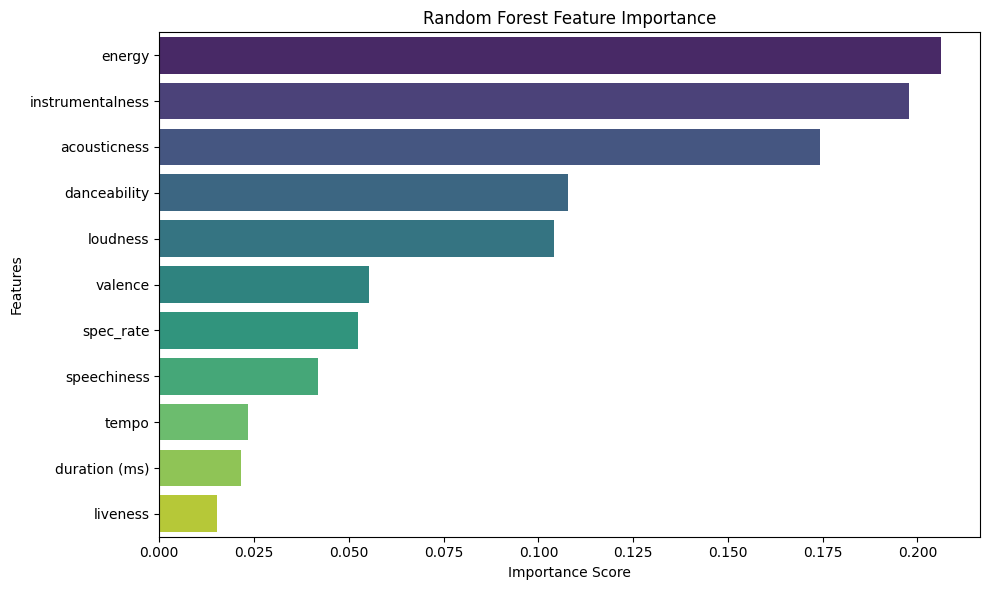

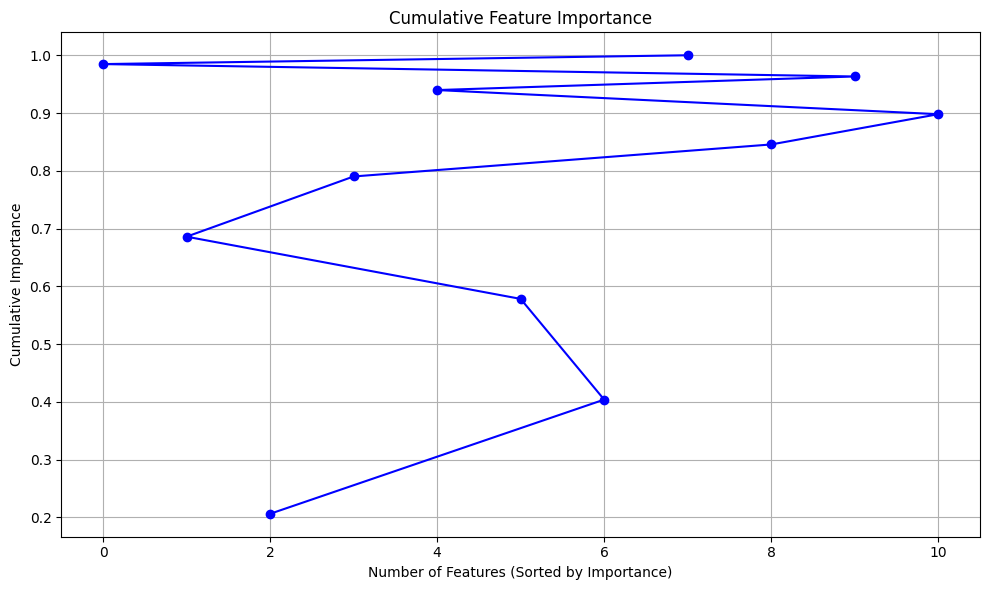

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- 數據載入與預處理 (與您提供的程式碼相同) ---
try:
    df = pd.read_csv('./Data/278k_song_labelled.csv')
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
    target = 'labels'
    if target not in df.columns:
        raise ValueError(f"Label column '{target}' not found in the DataFrame.")
    X = df.drop(target, axis=1)
    y = df[target]

    # 確保 train_test_split 使用的 random_state 和 stratify 與您之前訓練模型時一致
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 確保預處理步驟與訓練時一致
    scaler = StandardScaler()
    # 這裡使用 X_train 和 X_test 來 fit_transform 和 transform
    # 這樣確保了數據集的分離，雖然對於 feature importance 分析，
    # 嚴格來說只需要 X 的特徵名稱，但為了完整性，我們還是模擬這個流程。
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 由於 feature importance 與數據尺度無關，我們可以直接使用原始的 X
    # 但如果您的模型訓練時是基於 X_train_scaled，那麼在提取 feature importance 的時候
    # 最好也使用 X_train_scaled 的特徵名稱來對應。
    # 為了方便，這裡我們直接使用 X 的欄位名稱。
    feature_names = X.columns.tolist() 
    
    print("成功載入並處理了實際數據。")

except FileNotFoundError:
    print("警告: 找不到 './Data/278k_song_labelled.csv'。請確認檔案路徑。")
    # 如果檔案不存在，則無法繼續執行。
    exit()
except ValueError as ve:
    print(f"數據處理錯誤: {ve}")
    exit()
except Exception as e:
    print(f"發生預期外的錯誤: {e}")
    exit()

# --- 載入訓練好的 Random Forest 模型 ---
model_dir = 'saved_models'
model_filename = 'Random_Forest_best_model.joblib' # 根據您儲存的模型檔案名稱修改
model_path = os.path.join(model_dir, model_filename)

if not os.path.exists(model_path):
    print(f"錯誤: 模型檔案 '{model_path}' 不存在。請確保您已成功訓練並儲存了 Random Forest 模型。")
    exit()

try:
    loaded_model = joblib.load(model_path)
    print(f"成功載入模型: '{model_filename}'")
    
    # 檢查載入的模型是否為 RandomForestClassifier
    if not isinstance(loaded_model, RandomForestClassifier):
        print(f"警告: 載入的檔案 '{model_filename}' 並非 RandomForestClassifier 物件。")
        # 這裡可以選擇退出或嘗試繼續，取決於您的需求
        exit()

except Exception as e:
    print(f"載入模型時發生錯誤: {e}")
    exit()

# --- 提取 Feature Importance ---
# 確保模型已經被訓練過
if hasattr(loaded_model, 'feature_importances_'):
    feature_importances = loaded_model.feature_importances_
    
    # 創建一個 DataFrame 來儲存特徵名稱和它們的重要性分數
    # 這裡需要確保 feature_names 的數量與 feature_importances 的長度一致
    if len(feature_names) == len(feature_importances):
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importances
        })
        
        # 按重要性分數進行排序（從高到低）
        importance_df = importance_df.sort_values('importance', ascending=False)
        
        print("\n--- Random Forest Feature Importance ---")
        print(importance_df)
        
        # --- 視覺化 Feature Importance ---
        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
        plt.title('Random Forest Feature Importance')
        plt.xlabel('Importance Score')
        plt.ylabel('Features')
        plt.tight_layout()
        plt.show()
        
        # 也可以視覺化累積重要性
        importance_df['cumulative_importance'] = importance_df['importance'].cumsum()
        
        plt.figure(figsize=(10, 6))
        plt.plot(importance_df['cumulative_importance'], marker='o', linestyle='-', color='b')
        plt.title('Cumulative Feature Importance')
        plt.xlabel('Number of Features (Sorted by Importance)')
        plt.ylabel('Cumulative Importance')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
    else:
        print("錯誤: 特徵名稱的數量與模型提取的重要性分數數量不符。")
        print(f"特徵名稱數量: {len(feature_names)}")
        print(f"重要性分數數量: {len(feature_importances)}")
else:
    print("錯誤: 載入的模型沒有 'feature_importances_' 屬性，這表示它可能未被正確訓練或不是一個支援此屬性的模型。")

# SHAP

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib
import os
import shap # 引入 shap 庫
import matplotlib.pyplot as plt

# --- 載入數據和模型 (同上) ---
try:
    df = pd.read_csv('./Data/278k_song_labelled.csv')
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
    target = 'labels'
    if target not in df.columns:
        raise ValueError(f"Label column '{target}' not found in the DataFrame.")
    X = df.drop(target, axis=1)
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    feature_names = X.columns # 實際數據的特徵名稱
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_train_input = X_train_scaled
    X_test_input = X_test_scaled
    print("成功載入並處理了實際數據。")
except FileNotFoundError:
    print("警告: 找不到 './Data/278k_song_labelled.csv'。將使用模擬數據。")
    from sklearn.datasets import make_classification
    n_samples = 500
    n_features = 11
    n_classes = 4
    X_sim, y_sim = make_classification(
        n_samples=n_samples, n_features=n_features, n_informative=5, 
        n_redundant=2, n_classes=n_classes, n_clusters_per_class=2, random_state=42
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X_sim, y_sim, test_size=0.2, random_state=42, stratify=y_sim
    )
    scaler = StandardScaler()
    feature_names = [f'feature_{i}' for i in range(X_sim.shape[1])] # 模擬數據的假名字
    X_train_input = scaler.fit_transform(X_train)
    X_test_input = scaler.transform(X_test)
    print("已創建模擬數據。")
except ValueError as ve:
    print(f"數據處理錯誤: {ve}")
    exit()

# 確保輸入是 NumPy 陣列
X_train_np = np.array(X_train_input)
y_train_np = np.array(y_train)
X_test_np = np.array(X_test_input)
y_test_np = np.array(y_test)


# --- 載入訓練好的 Random Forest 模型 ---
model_dir = 'saved_models'
model_filename = os.path.join(model_dir, 'Random_Forest_best_model.joblib')

if os.path.exists(model_filename):
    print(f"正在載入模型: {model_filename}")
    loaded_rf_model = joblib.load(model_filename)
    print("模型載入成功。")

    # --- 使用 SHAP 進行特徵重要性分析 ---
    
    # 1. 創建 Explainer
    # 對於樹模型，TreeExplainer 是最高效的
    # 需要提供背景數據 (background dataset)，通常是訓練集的一部分或全部
    # 這裡使用 X_train_np 作為背景數據
    explainer = shap.TreeExplainer(loaded_rf_model) 

    # 2. 計算 SHAP 值
    # 這裡我們計算測試集 X_test_np 的 SHAP 值
    shap_values = explainer.shap_values(X_test_np)

    # 3. 獲取全局特徵重要性 (Summary Plot)
    # SHAP 的 summary_plot 可以根據 SHAP 值的絕對值來排序特徵，
    # 這與 Random Forest 的 feature_importances_ 類似，但 SHAP 的解釋更為嚴謹。
    # 对于多類別問題，shap_values 會是一個列表（每個類別一個陣列），
    # 或者一個陣列（如果模型輸出概率），TreeExplainer 會自動處理。
    
    # 如果是多類別問題，shap_values 會是個列表
    # 為了繪製 summary plot，我們通常使用平均絕對 SHAP 值
    # 這裡假設是多類別， Shap 值的計算需要注意
    
    # 重新計算 SHAP 值，確保對於多分類問題能正確處理
    # 如果模型是 classification 類別，shap_values 會是 list of arrays (one array per class)
    # 或者一個 array (if model outputs probabilities, e.g., predict_proba)
    # 這裡我們將使用 `predict_proba` 的輸出來計算 SHAP 值
    
    # 確保模型支援 predict_proba (RandomForestClassifier 支援)
    if hasattr(loaded_rf_model, "predict_proba"):
        print("模型支援 predict_proba，正在計算 SHAP 值...")
        # 針對所有類別的概率進行計算
        shap_values_proba = explainer.shap_values(X_test_np)
        
        # summary_plot 繪製的是對全局的影響，通常會有多個類別的 SHAP 值。
        # shap.summary_plot 預設會處理多類別的輸出。
        # 如果 shap_values_proba 是 list of arrays，summary_plot 會為每個類別繪製
        # 或者，我們可以取平均的 SHAP 值來獲得整體特徵重要性
        
        # 這裡直接繪製 summary_plot，SHAP 會自動處理多分類情況
        print("正在生成 SHAP Summary Plot (全局特徵重要性)...")
        shap.summary_plot(shap_values_proba, X_test_np, feature_names=list(feature_names), plot_type="bar")
        plt.title("SHAP Summary Plot (Global Feature Importance)")
        plt.show()

        # 也可以繪製 individual plot (每個點代表一個樣本)
        # print("正在生成 SHAP Summary Plot (帶樣本點)...")
        # shap.summary_plot(shap_values_proba, X_test_np, feature_names=list(feature_names))
        # plt.title("SHAP Summary Plot (Individual Feature Effects)")
        # plt.show()

    else:
        print("警告：模型不支援 predict_proba，無法計算 SHAP 值進行全局分析。")

    # --- 獲取單個預測的解釋 (Local Explanation) ---
    # 選擇一個測試樣本來解釋
    sample_index_to_explain = 0 
    print(f"\n正在解釋第 {sample_index_to_explain} 個測試樣本的預測結果...")
    
    # shap.force_plot 適合解釋單個預測
    # 我們需要獲取該樣本的 SHAP 值
    # 如果 shap_values_proba 是 list of arrays，需要選擇一個類別來解釋
    # 這裡我們以第一個類別（索引 0）的 SHAP 值為例
    
    # 獲取第一個樣本在所有類別上的 SHAP 值 (如果模型是多分類)
    # shap_values_for_sample = explainer.shap_values(X_test_np[sample_index_to_explain,:]) # 這是單個樣本的 SHAP 值
    
    # shap.force_plot 可以單獨解釋某個類別的預測，或者顯示所有類別的預測。
    # 為了顯示準確，我們需要一個基礎值 (expected_value)
    # 如果模型是多分類，expected_value 也會是個列表
    
    # 獲取預測的基礎值 (expected value)，表示所有樣本的平均預測值
    expected_value = explainer.expected_value

    # 選擇要解釋的類別
    class_to_explain = 1 # 例如，解釋預測為類別 1 的原因
    
    if isinstance(expected_value, list) and len(expected_value) > class_to_explain:
        sample_shap_values = explainer.shap_values(X_test_np[sample_index_to_explain, :])[class_to_explain]
        base_value = expected_value[class_to_explain]
        
        # shap.force_plot 繪製單個預測
        print(f"正在生成第 {sample_index_to_explain} 個樣本（預測類別 {class_to_explain}）的 SHAP Force Plot...")
        shap.force_plot(
            base_value=base_value,
            shap_values=sample_shap_values,
            features=X_test_np[sample_index_to_explain, :],
            feature_names=list(feature_names),
            matplotlib=True # 使用 matplotlib 進行繪製
        )
        plt.title(f"SHAP Force Plot for Sample {sample_index_to_explain} (Class {class_to_explain})")
        plt.show()
        
        # 也可以用 decision_plot 來視覺化某個樣本的 SHAP 值
        # shap.decision_plot(explainer.expected_value[class_to_explain], shap_values_for_sample, feature_names=feature_names)
        # plt.title(f"SHAP Decision Plot for Sample {sample_index_to_explain} (Class {class_to_explain})")
        # plt.show()

    else:
        print(f"警告：無法獲取基礎值或 SHAP 值來解釋類別 {class_to_explain}。")


else:
    print(f"錯誤：找不到模型檔案 '{model_filename}'。請先運行模型訓練部分。")

/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


成功載入並處理了實際數據。
正在載入模型: saved_models/Random_Forest_best_model.joblib
模型載入成功。
